In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq

In [8]:
books = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_book_data_feb_25.csv')
formats = pd.read_csv('/Users/nogashlomi/projects/Image_data/book_format.csv')

In [9]:
books

,book,label,bid,authors,publishers,printers,place,year,num_pages,year_interval,place_category
0,http://sphaera.mpiwg-berlin.mpg.de/id/item/83a...,Opus sphericum magistri Ioannis de Sacro busto,2118,"Sacrobosco, Johannes de",Company Heirs of Heinrich Quentell,Company Heirs of Heinrich Quentell,Cologne,1503,74,1490-1509,Medium Center
1,http://sphaera.mpiwg-berlin.mpg.de/id/item/8a2...,Introductorium compendiosum in Tractatum spere...,1860,"John of Glogów;Sacrobosco, Johannes de","Haller, Jan","Ungler, Florian",Kraków,1513,159,1510-1529,Small Center
2,http://sphaera.mpiwg-berlin.mpg.de/id/item/a09...,Sphaera Iani de Sacrobusto,1772,"Sacrobosco, Johannes de;Apianus, Petrus","Apianus, Petrus","Apianus, Petrus",Ingolstadt,1526,56,1510-1529,One Book Center
3,http://sphaera.mpiwg-berlin.mpg.de/id/item/57c...,"Quaestiones novae, in libellum de Sphaera Ioha...",2117,"Sacrobosco, Johannes de;Beyer, Hartmann","Braubach, Peter","Braubach, Peter",Frankfurt (Main),1549,176,1530-1549,Medium Center
4,http://sphaera.mpiwg-berlin.mpg.de/id/item/55b...,Sphaera Mundi,1865,"Sacrobosco, Johannes de","Cammerlander, Jacob","Cammerlander, Jacob",Strasbourg,1539,78,1530-1549,Small Center
...,...,...,...,...,...,...,...,...,...,...,...
354,http://sphaera.mpiwg-berlin.mpg.de/id/item/84b...,"In Sphaeram Ioannis de Sacro Bosco, commentarius",1821,"Sacrobosco, Johannes de;Clavius, Christoph","Crispin, Samuel","Crispin, Samuel",Saint Gervais,1602,595,1590-1609,Small Center
355,http://sphaera.mpiwg-berlin.mpg.de/id/item/924...,In Sphaeram Ioannis de Sacro Bosco. Commentarius,1817,"Clavius, Christoph;Sacrobosco, Johannes de","Gelli, Giovanni Paolo","Zanetti, Luigi",Rome,1607,720,1590-1609,Small Center
356,http://sphaera.mpiwg-berlin.mpg.de/id/item/95c...,"De sphaera, seu primi mobilis rudimentis libellus",2183,"Regiomontanus, Johannes;Blebel, Thomas",Company Heirs of Samuel Selfisch,Company Heirs of Andreas Kelner,Wittenberg,1616,288,1610-1629,Large Center
357,http://sphaera.mpiwg-berlin.mpg.de/id/item/97c...,Sphaera Ioannis de Sacro Bosco,1972,"Vinet, Élie;Nunes, Pedro;Valeriano, Pierio;Sac...",Company Heirs of Girolamo Scoto,Company Heirs of Girolamo Scoto,Venice,1620,173,1610-1629,Large Center


In [10]:
formats

,bid,short_title,format_label
0,2062,,Quarto
1,1786,,Octavo
2,1730,,Octavo
3,2190,,Folio
4,1694,,Octavo
...,...,...,...
472,16002,,Quarto
473,16003,,Folio
474,16001,,Quarto
475,10074,,Quarto


In [14]:
# Clean column names for both DataFrames
books.columns = books.columns.str.strip().str.lower()
formats.columns = formats.columns.str.strip().str.lower()

# Now both should have 'bid' as the column
books_bids = set(books["bid"])
formats_bids = set(formats["bid"])

# Compare
common_bids = books_bids & formats_bids
books_only = books_bids - formats_bids
formats_only = formats_bids - books_bids

# Counts
print("Counts:")
print("Common bids:", len(common_bids))
print("Only in books:", len(books_only))
print("Only in formats:", len(formats_only))

# Optional: DataFrames of unique entries
books_only_df = books[books["bid"].isin(books_only)]
formats_only_df = formats[formats["bid"].isin(formats_only)]

print("\nBooks only:")
print(books_only_df)
print("\nFormats only:")
print(formats_only_df)


Counts:
Common bids: 359
Only in books: 0
Only in formats: 118

Books only:
Empty DataFrame
Columns: [book, label, bid, authors, publishers, printers, place, year, num_pages, year_interval, place_category]
Index: []

Formats only:
       bid short_title format_label
300  10041                 Quarto  
301  10042                  Folio  
302  10043                  Folio  
303  10044                 Octavo  
304  10045                 Quarto  
..     ...         ...          ...
472  16002                 Quarto  
473  16003                  Folio  
474  16001                 Quarto  
475  10074                 Quarto  
476  15039                 Octavo  

[118 rows x 3 columns]


In [16]:
# Merge formats into books to add a new column 'format'
books = books.merge(
    formats[['bid', 'format_label']],  # only take bid and format_label
    on='bid',                          # merge on bid
    how='left'                         # keep only books rows
)

# Rename the column to 'format'
books = books.rename(columns={'format_label': 'format'})

# Check the result
books

,book,label,bid,authors,publishers,printers,place,year,num_pages,year_interval,place_category,format,format
0,http://sphaera.mpiwg-berlin.mpg.de/id/item/83a...,Opus sphericum magistri Ioannis de Sacro busto,2118,"Sacrobosco, Johannes de",Company Heirs of Heinrich Quentell,Company Heirs of Heinrich Quentell,Cologne,1503,74,1490-1509,Medium Center,Quarto,Quarto
1,http://sphaera.mpiwg-berlin.mpg.de/id/item/8a2...,Introductorium compendiosum in Tractatum spere...,1860,"John of Glogów;Sacrobosco, Johannes de","Haller, Jan","Ungler, Florian",Kraków,1513,159,1510-1529,Small Center,Quarto,Quarto
2,http://sphaera.mpiwg-berlin.mpg.de/id/item/a09...,Sphaera Iani de Sacrobusto,1772,"Sacrobosco, Johannes de;Apianus, Petrus","Apianus, Petrus","Apianus, Petrus",Ingolstadt,1526,56,1510-1529,One Book Center,Octavo,Octavo
3,http://sphaera.mpiwg-berlin.mpg.de/id/item/57c...,"Quaestiones novae, in libellum de Sphaera Ioha...",2117,"Sacrobosco, Johannes de;Beyer, Hartmann","Braubach, Peter","Braubach, Peter",Frankfurt (Main),1549,176,1530-1549,Medium Center,Octavo,Octavo
4,http://sphaera.mpiwg-berlin.mpg.de/id/item/55b...,Sphaera Mundi,1865,"Sacrobosco, Johannes de","Cammerlander, Jacob","Cammerlander, Jacob",Strasbourg,1539,78,1530-1549,Small Center,Quarto,Quarto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,http://sphaera.mpiwg-berlin.mpg.de/id/item/84b...,"In Sphaeram Ioannis de Sacro Bosco, commentarius",1821,"Sacrobosco, Johannes de;Clavius, Christoph","Crispin, Samuel","Crispin, Samuel",Saint Gervais,1602,595,1590-1609,Small Center,Quarto,Quarto
355,http://sphaera.mpiwg-berlin.mpg.de/id/item/924...,In Sphaeram Ioannis de Sacro Bosco. Commentarius,1817,"Clavius, Christoph;Sacrobosco, Johannes de","Gelli, Giovanni Paolo","Zanetti, Luigi",Rome,1607,720,1590-1609,Small Center,Quarto,Quarto
356,http://sphaera.mpiwg-berlin.mpg.de/id/item/95c...,"De sphaera, seu primi mobilis rudimentis libellus",2183,"Regiomontanus, Johannes;Blebel, Thomas",Company Heirs of Samuel Selfisch,Company Heirs of Andreas Kelner,Wittenberg,1616,288,1610-1629,Large Center,Octavo,Octavo
357,http://sphaera.mpiwg-berlin.mpg.de/id/item/97c...,Sphaera Ioannis de Sacro Bosco,1972,"Vinet, Élie;Nunes, Pedro;Valeriano, Pierio;Sac...",Company Heirs of Girolamo Scoto,Company Heirs of Girolamo Scoto,Venice,1620,173,1610-1629,Large Center,Octavo,Octavo


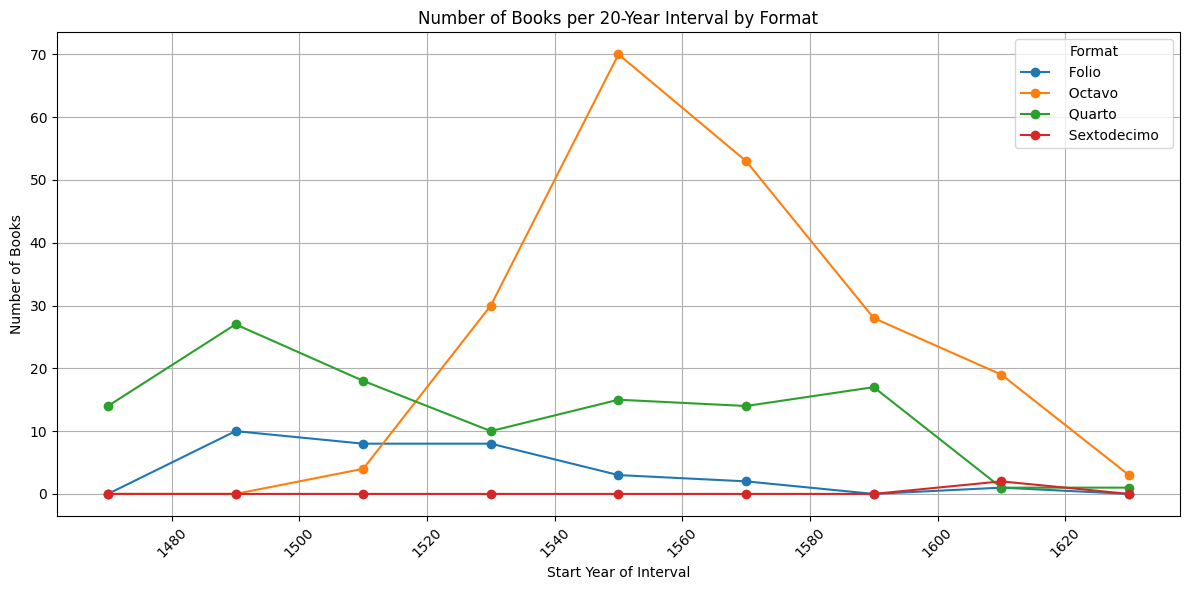

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Drop duplicate columns if present
books = books.loc[:, ~books.columns.duplicated()]

# Keep only rows with non-missing year_interval and format
books_plot = books.dropna(subset=['year_interval', 'format']).copy()

# Strip whitespace from year_interval
books_plot['year_interval'] = books_plot['year_interval'].str.strip()

# Extract start year safely
def safe_start_year(interval):
    try:
        return int(interval.split('-')[0])
    except:
        return None  # skip invalid entries

books_plot['start_year'] = books_plot['year_interval'].apply(safe_start_year)

# Drop rows where start_year could not be parsed
books_plot = books_plot.dropna(subset=['start_year'])

# Convert start_year to int
books_plot['start_year'] = books_plot['start_year'].astype(int)

# Group by start_year and format, count books
interval_format_counts = books_plot.groupby(['start_year', 'format']).size().reset_index(name='count')

# Pivot for plotting
pivot_df = interval_format_counts.pivot(index='start_year', columns='format', values='count').fillna(0)

# Plot line graph
pivot_df.plot(kind='line', marker='o', figsize=(12, 6))

plt.title("Number of Books per 20-Year Interval by Format")
plt.xlabel("Start Year of Interval")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Format")
plt.tight_layout()
plt.show()


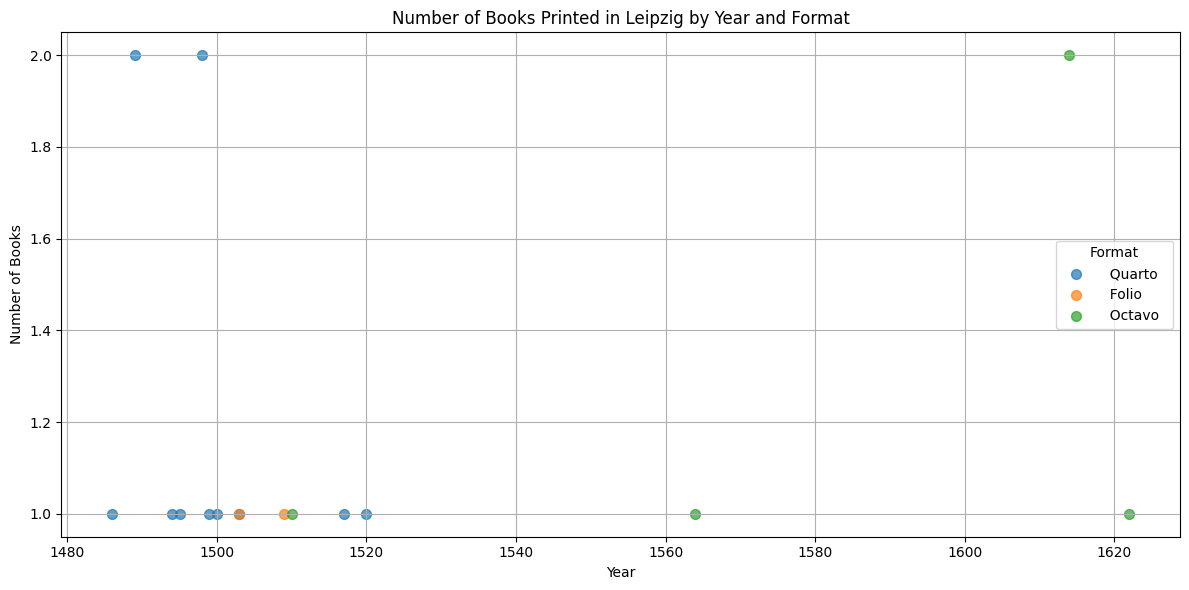

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Drop duplicate columns if present
books = books.loc[:, ~books.columns.duplicated()]

# Keep only rows with non-missing year, place, and format
books_plot = books.dropna(subset=['year', 'place', 'format']).copy()

# Filter for Leipzig
books_leipzig = books_plot[books_plot['place'].str.strip().str.lower() == 'leipzig'].copy()

# Make sure year is numeric
books_leipzig['year'] = pd.to_numeric(books_leipzig['year'], errors='coerce')
books_leipzig = books_leipzig.dropna(subset=['year'])
books_leipzig['year'] = books_leipzig['year'].astype(int)

# Group by year and format, count books
year_format_counts = books_leipzig.groupby(['year', 'format']).size().reset_index(name='count')

# Plot scatter plot
plt.figure(figsize=(12, 6))
for fmt in year_format_counts['format'].unique():
    subset = year_format_counts[year_format_counts['format'] == fmt]
    plt.scatter(subset['year'], subset['count'], label=fmt, s=50, alpha=0.7)

plt.title("Number of Books Printed in Leipzig by Year and Format")
plt.xlabel("Year")
plt.ylabel("Number of Books")
plt.legend(title="Format")
plt.grid(True)
plt.tight_layout()
plt.show()


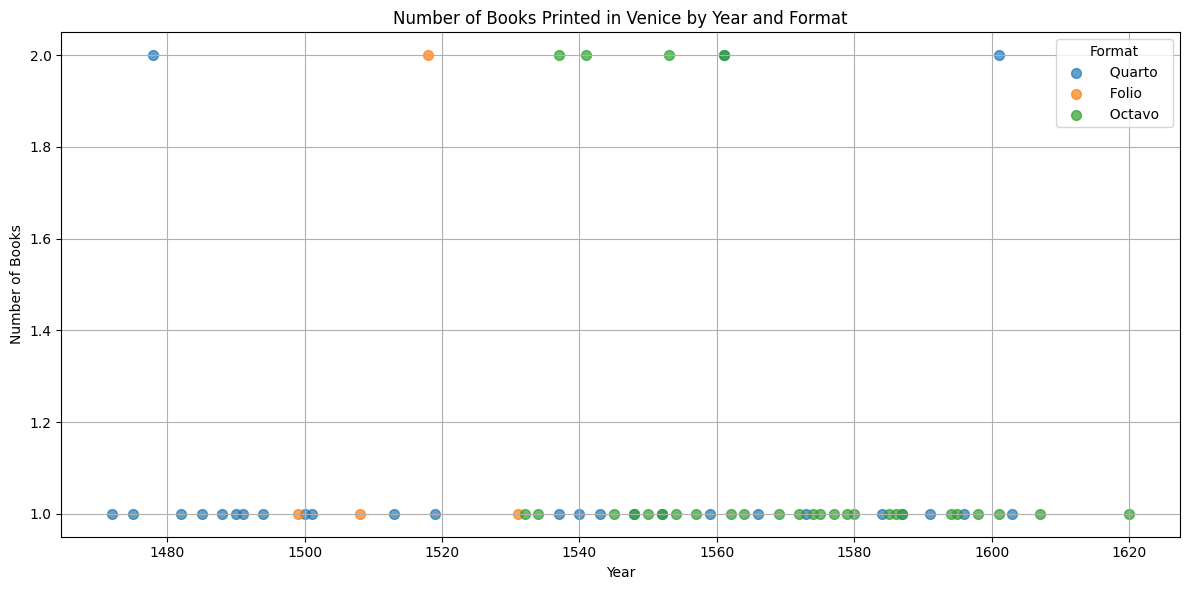

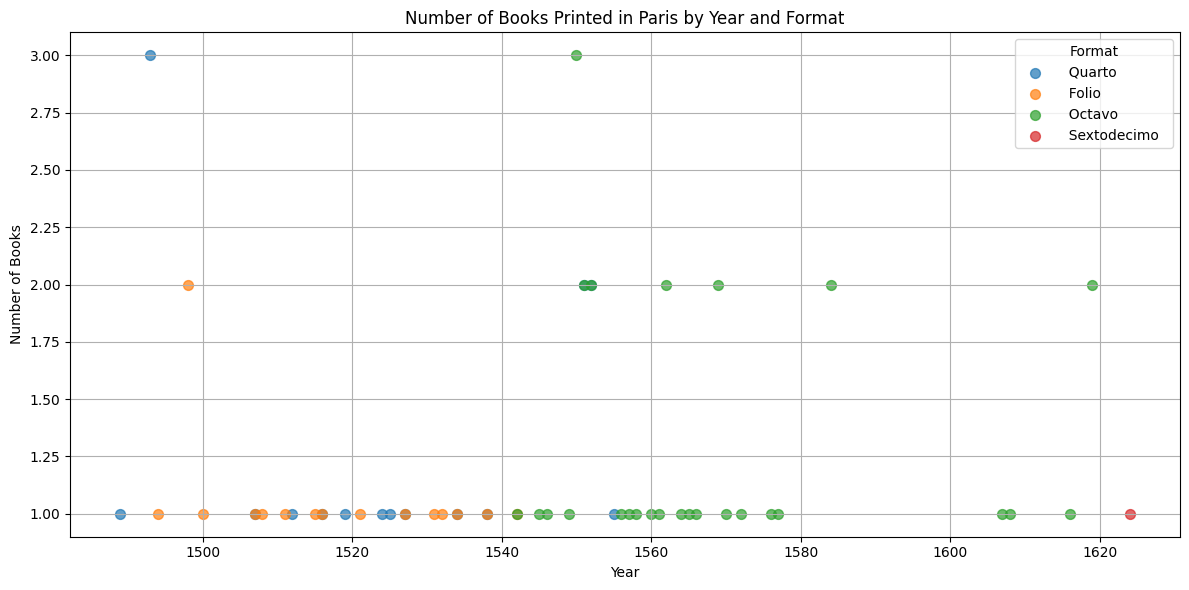

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Drop duplicate columns if present
books = books.loc[:, ~books.columns.duplicated()]

# Keep only rows with non-missing year, place, and format
books_plot = books.dropna(subset=['year', 'place', 'format']).copy()

# Make sure year is numeric
books_plot['year'] = pd.to_numeric(books_plot['year'], errors='coerce')
books_plot = books_plot.dropna(subset=['year'])
books_plot['year'] = books_plot['year'].astype(int)

# Function to plot scatter for a given city
def plot_books_by_city(city_name):
    city_books = books_plot[books_plot['place'].str.strip().str.lower() == city_name.lower()]
    if city_books.empty:
        print(f"No data for {city_name}")
        return
    
    # Group by year and format
    year_format_counts = city_books.groupby(['year', 'format']).size().reset_index(name='count')
    
    # Plot scatter
    plt.figure(figsize=(12, 6))
    for fmt in year_format_counts['format'].unique():
        subset = year_format_counts[year_format_counts['format'] == fmt]
        plt.scatter(subset['year'], subset['count'], label=fmt, s=50, alpha=0.7)
    
    plt.title(f"Number of Books Printed in {city_name} by Year and Format")
    plt.xlabel("Year")
    plt.ylabel("Number of Books")
    plt.legend(title="Format")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for Venice
plot_books_by_city("Venice")

# Plot for Paris
plot_books_by_city("Paris")


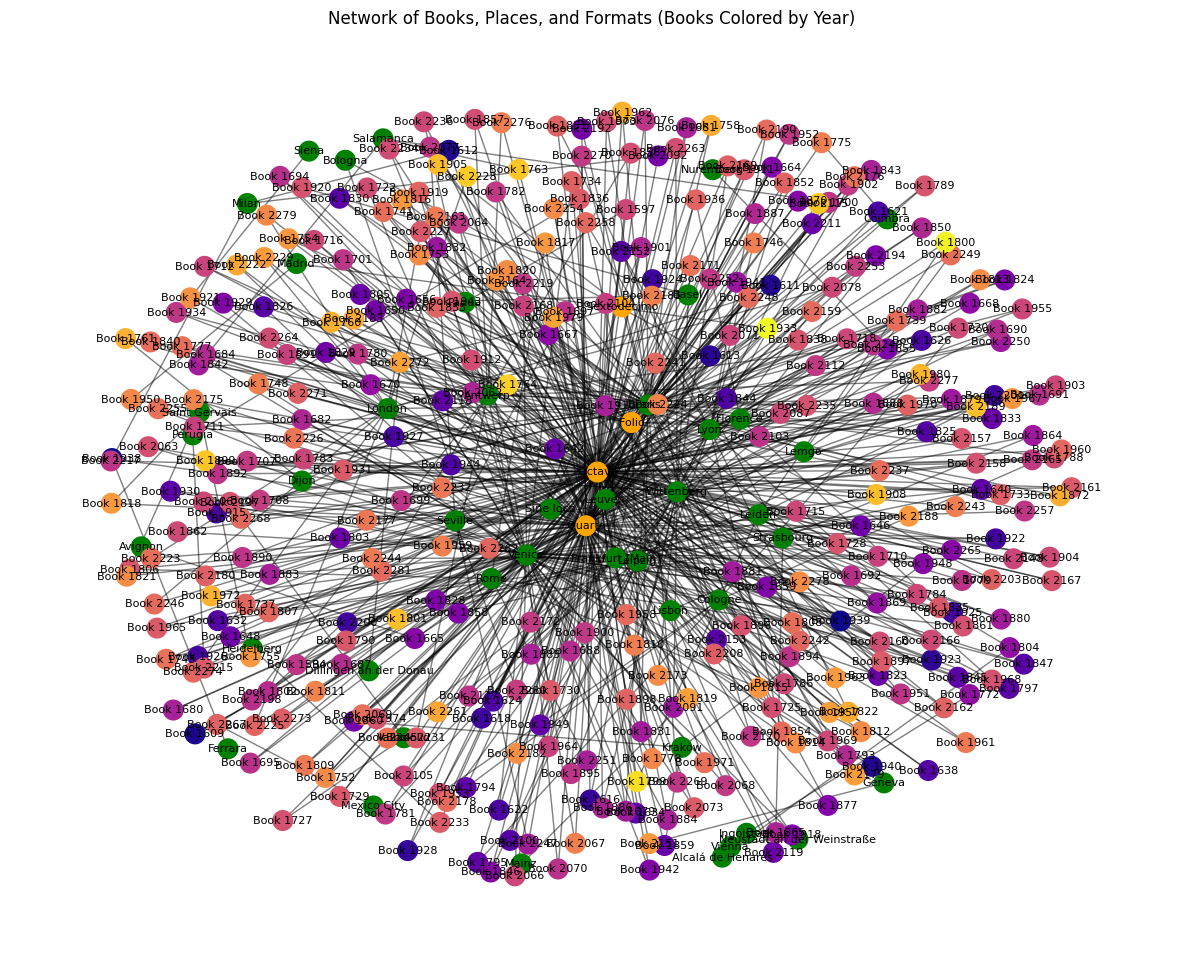

In [25]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Drop duplicate columns if present
books = books.loc[:, ~books.columns.duplicated()]

# Keep only rows with year, place, format, and bid (book id)
books_net = books.dropna(subset=['year', 'place', 'format', 'bid']).copy()

# Make sure year is numeric
books_net['year'] = pd.to_numeric(books_net['year'], errors='coerce')
books_net = books_net.dropna(subset=['year'])
books_net['year'] = books_net['year'].astype(int)

# Create NetworkX graph
G = nx.Graph()

# Add nodes
# Place nodes
places = books_net['place'].unique()
G.add_nodes_from(places, type='place')

# Format nodes
formats = books_net['format'].unique()
G.add_nodes_from(formats, type='format')

# Book nodes
for idx, row in books_net.iterrows():
    book_node = f"Book {row['bid']}"  # unique book node
    G.add_node(book_node, type='book', year=row['year'])
    
    # Connect book to its place
    G.add_edge(book_node, row['place'])
    
    # Connect book to its format
    G.add_edge(book_node, row['format'])

# Draw the network
plt.figure(figsize=(15, 12))

# Assign colors by node type
color_map = []
for node in G.nodes(data=True):
    if node[1]['type'] == 'book':
        # Color code by year (early = blue, late = red)
        year = node[1]['year']
        # normalize year to 0-1 for colormap
        min_year = books_net['year'].min()
        max_year = books_net['year'].max()
        norm_year = (year - min_year) / (max_year - min_year)
        color_map.append(plt.cm.plasma(norm_year))
    elif node[1]['type'] == 'place':
        color_map.append('green')
    elif node[1]['type'] == 'format':
        color_map.append('orange')

# Layout
pos = nx.spring_layout(G, k=0.5, seed=42)

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=200)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Network of Books, Places, and Formats (Books Colored by Year)")
plt.axis('off')
plt.show()


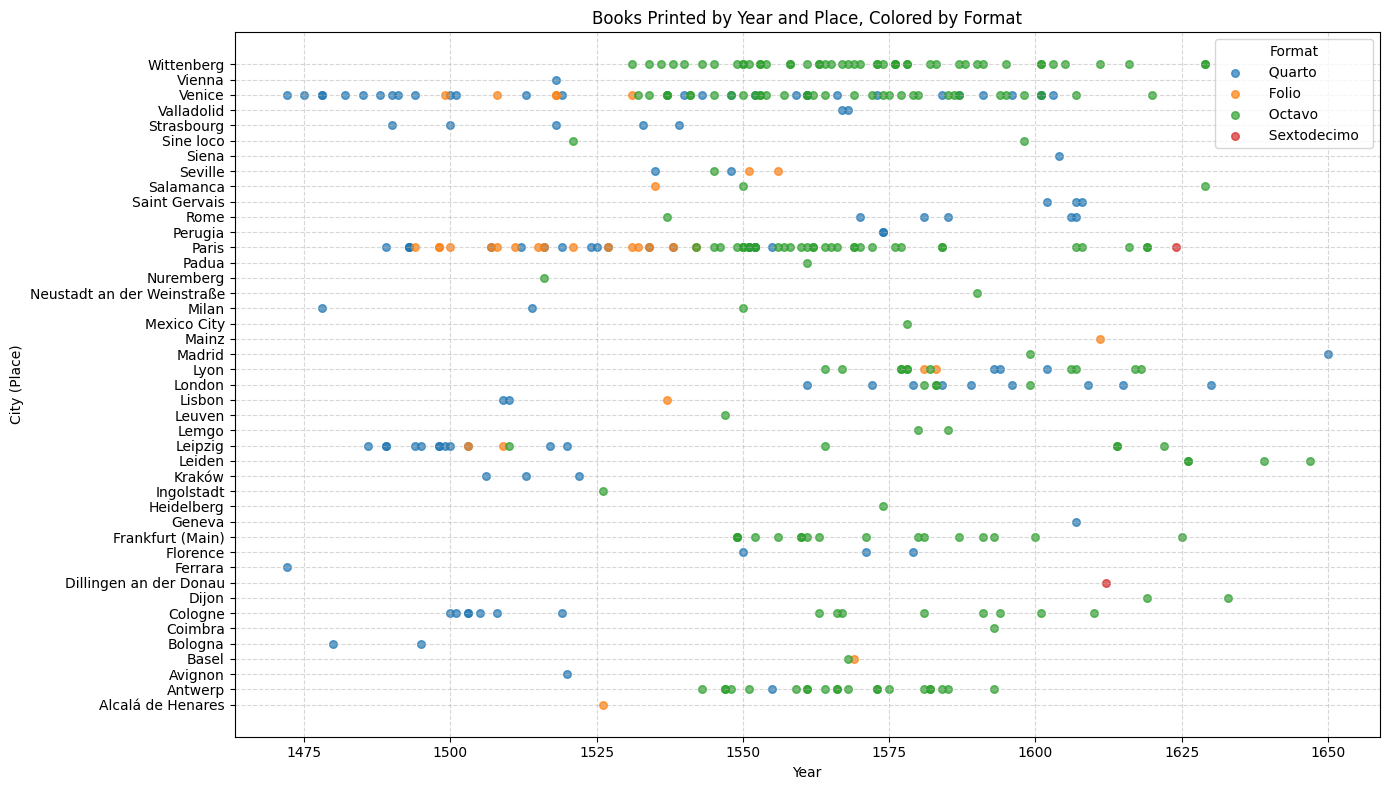

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Drop duplicate columns if present
books = books.loc[:, ~books.columns.duplicated()]

# Keep only rows with year, place, and format
books_plot = books.dropna(subset=['year', 'place', 'format']).copy()

# Make sure year is numeric
books_plot['year'] = pd.to_numeric(books_plot['year'], errors='coerce')
books_plot = books_plot.dropna(subset=['year'])
books_plot['year'] = books_plot['year'].astype(int)

# Get unique places and assign numeric positions for y-axis
places = sorted(books_plot['place'].unique())
place_to_num = {place: i for i, place in enumerate(places)}
books_plot['place_num'] = books_plot['place'].map(place_to_num)

# Create scatter plot
plt.figure(figsize=(14, 8))
formats = books_plot['format'].unique()
for fmt in formats:
    subset = books_plot[books_plot['format'] == fmt]
    plt.scatter(subset['year'], subset['place_num'], label=fmt, alpha=0.7, s=30)

# Set y-axis labels as city names
plt.yticks(range(len(places)), places)
plt.xlabel("Year")
plt.ylabel("City (Place)")
plt.title("Books Printed by Year and Place, Colored by Format")
plt.legend(title="Format")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
